# Bayes最適化<BR>
<div style="text-align: right;">
Feb. 2023 初版作成：中山将伸<BR>
Nov. 2025 改訂(グラフ追加)：中山将伸<BR>

</div>


# ユーザー入力および関数

In [1]:
##################################################################################################
#                                 ユーザーが入力すべき箇所
##################################################################################################

#タスク１で使うファイル
path1=str("./candidates_easy.csv")
path1out=str("./afterBO.csv")

#目的変数の列ラベル
target_column = 'open'
#記述子を定義する列のラベル
desc_columns = ['conc_1','conc_2','conc_3','conc_4','conc_5']

#GP, BOに関するパラメーター
optnum=10    # ハイパーパラメーターのチューニング回数（尤度を最大化する　０でも一回は最適化する）
alp=0.0001  # GPを安定化するためのパラメーター
tradeoff_e_val=0  # BO(EI戦略)のトレードオフパラメーター

batch_size=3  # 並列提案数　（3以上行うことを勧める)

##################################################################################################


import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import sklearn.gaussian_process as gp
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
import random
import itertools

%matplotlib inline

def gpr(train_nx,train_ny):
    kk=gp.kernels.RBF() * gp.kernels.ConstantKernel() #+ gp.kernels.WhiteKernel()
    #kk=gp.kernels.RBF(length_scale=2) 
    #kk=gp.kernels.Matern(nu=5)
    #kk=gp.kernels.Matern(nu=5) + gp.kernels.WhiteKernel()

    gpm = gp.GaussianProcessRegressor(kernel=kk,alpha=alp, n_restarts_optimizer=optnum, normalize_y=True)
    gpm.fit(train_nx, train_ny) 
    
    return gpm

def gpp(unknown_x,gpm):

    GPf, GPv = gpm.predict(unknown_x, return_cov=True)  # 予測値と分散共分散行列
    GPf = np.array(GPf).reshape(-1,1)
    GPsd = np.sqrt(np.diag(GPv)).reshape(-1,1)                   # 予測値の標準偏差
    return GPf, GPv, GPsd

    
def expected_improvement(func_value_xpoint,sigma_xpoint,func_value_best, tradeoff_e_val):
    
    fvx = func_value_xpoint
    sx = sigma_xpoint
    fvb = func_value_best
    te = tradeoff_e_val
    Z = (fvx-fvb-te)/sx
    ei = ((fvx-fvb-te)*norm.cdf(Z))+(sx*norm.pdf(Z))
    return ei 

import numpy as np
import pandas as pd

def rank_candidates_sequential_fantasy(
    df_original,
    feature_cols,
    target_column="truth",
    open_column="open",
    batch_size=3,
    tradeoff_e_val=0.0,
    fantasy_mode="mean"
):
    """
    Sequential fantasy ranking for parallel BO.

    Parameters
    ----------
    df_original : pandas.DataFrame
        Original dataframe including descriptors, target, and open columns.
    feature_cols : list of str
        Descriptor column names.
    target_column : str
        Column name of true target. Used only for reference/output.
    open_column : str
        Observed-value column. Observed rows are non-null.
    batch_size : int
        Number of parallel candidates to propose.
    tradeoff_e_val : float
        EI tradeoff parameter.
    fantasy_mode : str
        "mean" : use GP predictive mean as fantasy observation
        "ucb"  : use mu + sd as optimistic fantasy
        "lcb"  : use mu - sd as pessimistic fantasy

    Returns
    -------
    df_ranked : pandas.DataFrame
        Candidate dataframe with sequential fantasy rank info.
    batch_indices : list
        Original dataframe indices selected as batch suggestions.
    batch_rows : pandas.DataFrame
        Selected rows in order.
    """
    df = df_original.copy()

    observed_mask = df[open_column].notna()
    candidate_mask = df[open_column].isna()

    train_x = df.loc[observed_mask, feature_cols].values.astype(float)
    train_y = df.loc[observed_mask, open_column].values.astype(float).reshape(-1, 1)

    cand_df = df.loc[candidate_mask].copy()
    cand_x = cand_df[feature_cols].values.astype(float)

    remaining_idx = cand_df.index.to_numpy()
    remaining_x = cand_x.copy()

    selected_indices = []
    selected_rows = []

    history = []

    for step in range(batch_size):
        if remaining_x.shape[0] == 0:
            break

        gpm = gpr(train_x, train_y)

        mu, var, sd = gpp(remaining_x, gpm)
        mu = np.asarray(mu).reshape(-1, 1)
        sd = np.asarray(sd).reshape(-1, 1)

        current_ymax = float(np.max(train_y))
        ei = expected_improvement(mu, sd, current_ymax, tradeoff_e_val)
        ei = np.asarray(ei).reshape(-1)

        best_local_id = int(np.argmax(ei))
        best_global_index = remaining_idx[best_local_id]

        best_mu = float(mu[best_local_id, 0])
        best_sd = float(sd[best_local_id, 0])
        best_ei = float(ei[best_local_id])

        if fantasy_mode == "mean":
            fantasy_y = best_mu
        elif fantasy_mode == "ucb":
            fantasy_y = best_mu + best_sd
        elif fantasy_mode == "lcb":
            fantasy_y = best_mu - best_sd
        else:
            raise ValueError("fantasy_mode must be 'mean', 'ucb', or 'lcb'")

        row_info = df.loc[best_global_index].copy()
        row_info["batch_rank"] = step + 1
        row_info["fantasy_mu"] = best_mu
        row_info["fantasy_sd"] = best_sd
        row_info["fantasy_ei"] = best_ei
        row_info["fantasy_y_used"] = fantasy_y

        selected_indices.append(best_global_index)
        selected_rows.append(row_info)
        history.append({
            "index": best_global_index,
            "batch_rank": step + 1,
            "fantasy_mu": best_mu,
            "fantasy_sd": best_sd,
            "fantasy_ei": best_ei,
            "fantasy_y_used": fantasy_y
        })

        x_new = remaining_x[best_local_id:best_local_id+1, :]
        y_new = np.array([[fantasy_y]], dtype=float)

        train_x = np.vstack([train_x, x_new])
        train_y = np.vstack([train_y, y_new])

        keep_mask = np.ones(len(remaining_idx), dtype=bool)
        keep_mask[best_local_id] = False
        remaining_idx = remaining_idx[keep_mask]
        remaining_x = remaining_x[keep_mask, :]

    hist_df = pd.DataFrame(history)

    df_ranked = df.copy()
    df_ranked["batch_rank"] = np.nan
    df_ranked["fantasy_mu"] = np.nan
    df_ranked["fantasy_sd"] = np.nan
    df_ranked["fantasy_ei"] = np.nan
    df_ranked["fantasy_y_used"] = np.nan

    # for _, r in hist_df.iterrows():
    #     idx = r["index"]
    #     df_ranked.loc[idx, "batch_rank"] = r["batch_rank"]
    #     df_ranked.loc[idx, "fantasy_mu"] = r["fantasy_mu"]
    #     df_ranked.loc[idx, "fantasy_sd"] = r["fantasy_sd"]
    #     df_ranked.loc[idx, "fantasy_ei"] = r["fantasy_ei"]
    #     df_ranked.loc[idx, "fantasy_y_used"] = r["fantasy_y_used"]

    # df_ranked = df_ranked.sort_values(
    #     by=["batch_rank", "fantasy_ei"],
    #     ascending=[True, False],
    #     na_position="last"
    # )

    for _, r in hist_df.iterrows():
        idx = r["index"]
        df_ranked.loc[idx, "batch_rank"] = r["batch_rank"]
        df_ranked.loc[idx, "fantasy_mu"] = r["fantasy_mu"]
        df_ranked.loc[idx, "fantasy_sd"] = r["fantasy_sd"]
        df_ranked.loc[idx, "fantasy_ei"] = r["fantasy_ei"]
        df_ranked.loc[idx, "fantasy_y_used"] = r["fantasy_y_used"]

    # Filled column:
    # - use observed open if available
    # - otherwise use fantasy_y_used for selected batch candidates
    # - otherwise remain NaN
    df_ranked["open_or_fantasy"] = df_ranked[open_column].copy()
    fill_mask = df_ranked["open_or_fantasy"].isna() & df_ranked["fantasy_y_used"].notna()
    df_ranked.loc[fill_mask, "open_or_fantasy"] = df_ranked.loc[fill_mask, "fantasy_y_used"]

    df_ranked = df_ranked.sort_values(
        by=["batch_rank", "fantasy_ei"],
        ascending=[True, False],
        na_position="last"
    )

    batch_rows = pd.DataFrame(selected_rows)

    return df_ranked, selected_indices, batch_rows


def plot_2ddescriptors(x1, x2, y, size):

    plt.figure(figsize=(8, 6))

    sc = plt.scatter(
        x1, x2,
        c=y,                 # 色は目的変数で
        cmap="jet",          # jet カラーマップ
        s=size,               # マーカーサイズ    
        edgecolor='k'
    )

    plt.xlabel("Descriptor 1")
    plt.ylabel("Descriptor 2")
    plt.title("2D Descriptors Colored by Target")

    plt.colorbar(sc, label="Target Value")
    plt.tight_layout()
    plt.show()
    return



def plot_nd_descriptors_allpairs_filtered(
    X,
    y,
    size=100,
    cmap="turbo",
    feature_names=None,
    colorbar_label="Target Value",
    ncols=3,
    xlim=(-0.02, 0.52),
    ylim=(-0.02, 0.52),
    use_colorbar=True,
    exclude_both_zero=True,
    zero_tol=1e-12
):
    """
    All-pairs 2D scatter plots.

    For each pair (Di, Dj), only samples are plotted where:
      - all other descriptors are zero (within zero_tol)
      - optionally exclude points where both Di and Dj are zero

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
    y : array-like, shape (n_samples,)
    size : scalar or array-like, shape (n_samples,)
        Marker size control.
        - scalar: same size for all points
        - array-like: point-wise sizes, same length as n_samples
    use_colorbar : bool
        Default is True.
    """

    X = np.asarray(X)
    y = np.asarray(y).flatten()

    if X.ndim != 2:
        raise ValueError("X must be 2D: (n_samples, n_features)")

    n_samples, n_features = X.shape

    if y.shape[0] != n_samples:
        raise ValueError("Length of y must match number of rows in X.")

    if n_features < 2:
        raise ValueError("Need at least 2 descriptor dimensions.")

    if feature_names is None:
        feature_names = [f"D{i+1}" for i in range(n_features)]
    else:
        if len(feature_names) != n_features:
            raise ValueError("feature_names length must match n_features.")

    # Normalize size input
    if np.isscalar(size):
        size_array = np.full(n_samples, float(size))
    else:
        size_array = np.asarray(size).flatten()
        if size_array.shape[0] != n_samples:
            raise ValueError("If size is array-like, its length must equal number of samples.")

    pairs = list(itertools.combinations(range(n_features), 2))
    n_plots = len(pairs)

    ncols = min(ncols, n_plots)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.0 * ncols + (1.2 if use_colorbar else 0.0), 4.5 * nrows),
        squeeze=False,
        constrained_layout=True
    )
    axes = axes.flatten()

    vmin = np.min(y)
    vmax = np.max(y)

    used_axes = []
    sc_for_colorbar = None

    for k, (i, j) in enumerate(pairs):
        ax = axes[k]
        used_axes.append(ax)

        other_idx = [m for m in range(n_features) if m not in (i, j)]

        if len(other_idx) > 0:
            other_zero_mask = np.all(np.abs(X[:, other_idx]) <= zero_tol, axis=1)
        else:
            other_zero_mask = np.ones(n_samples, dtype=bool)

        if exclude_both_zero:
            pair_nonzero_mask = (np.abs(X[:, i]) > zero_tol) | (np.abs(X[:, j]) > zero_tol)
        else:
            pair_nonzero_mask = np.ones(n_samples, dtype=bool)

        mask = other_zero_mask & pair_nonzero_mask

        Xp = X[mask, i]
        Yp = X[mask, j]
        yp = y[mask]
        sp = size_array[mask]

        if use_colorbar:
            sc = ax.scatter(
                Xp,
                Yp,
                c=yp,
                cmap=cmap,
                s=sp,
                edgecolors="k",
                linewidths=0.8,
                vmin=vmin,
                vmax=vmax
            )
            if sc_for_colorbar is None and len(yp) > 0:
                sc_for_colorbar = sc
        else:
            ax.scatter(
                Xp,
                Yp,
                color="tab:blue",
                s=sp,
                edgecolors="k",
                linewidths=0.8
            )

        ax.set_xlabel(feature_names[i], fontsize=12)
        ax.set_ylabel(feature_names[j], fontsize=12)

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        ax.set_xticks(np.arange(0.0, 0.51, 0.1))
        ax.set_yticks(np.arange(0.0, 0.51, 0.1))
        ax.grid(alpha=0.3)

    for k in range(n_plots, len(axes)):
        axes[k].axis("off")

    if use_colorbar and sc_for_colorbar is not None:
        cbar = fig.colorbar(
            sc_for_colorbar,
            ax=used_axes,
            location="right",
            shrink=0.85,
            pad=0.02
        )
        cbar.set_label(colorbar_label, fontsize=12)

    plt.show()


# データの読み込み

,conc_1,conc_2,conc_3,conc_4,conc_5,truth,open
id,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,100.000000,NaN
1,0.0,0.0,0.0,0.0,0.1,109.018989,NaN
2,0.0,0.0,0.0,0.0,0.2,117.737777,NaN
3,0.0,0.0,0.0,0.0,0.3,126.168253,NaN
4,0.0,0.0,0.0,0.0,0.4,133.797213,NaN
...,...,...,...,...,...,...,...
271,0.5,0.1,0.0,0.0,0.0,135.003115,NaN
272,0.5,0.2,0.0,0.0,0.0,136.549824,NaN
273,0.5,0.3,0.0,0.0,0.0,137.820003,NaN


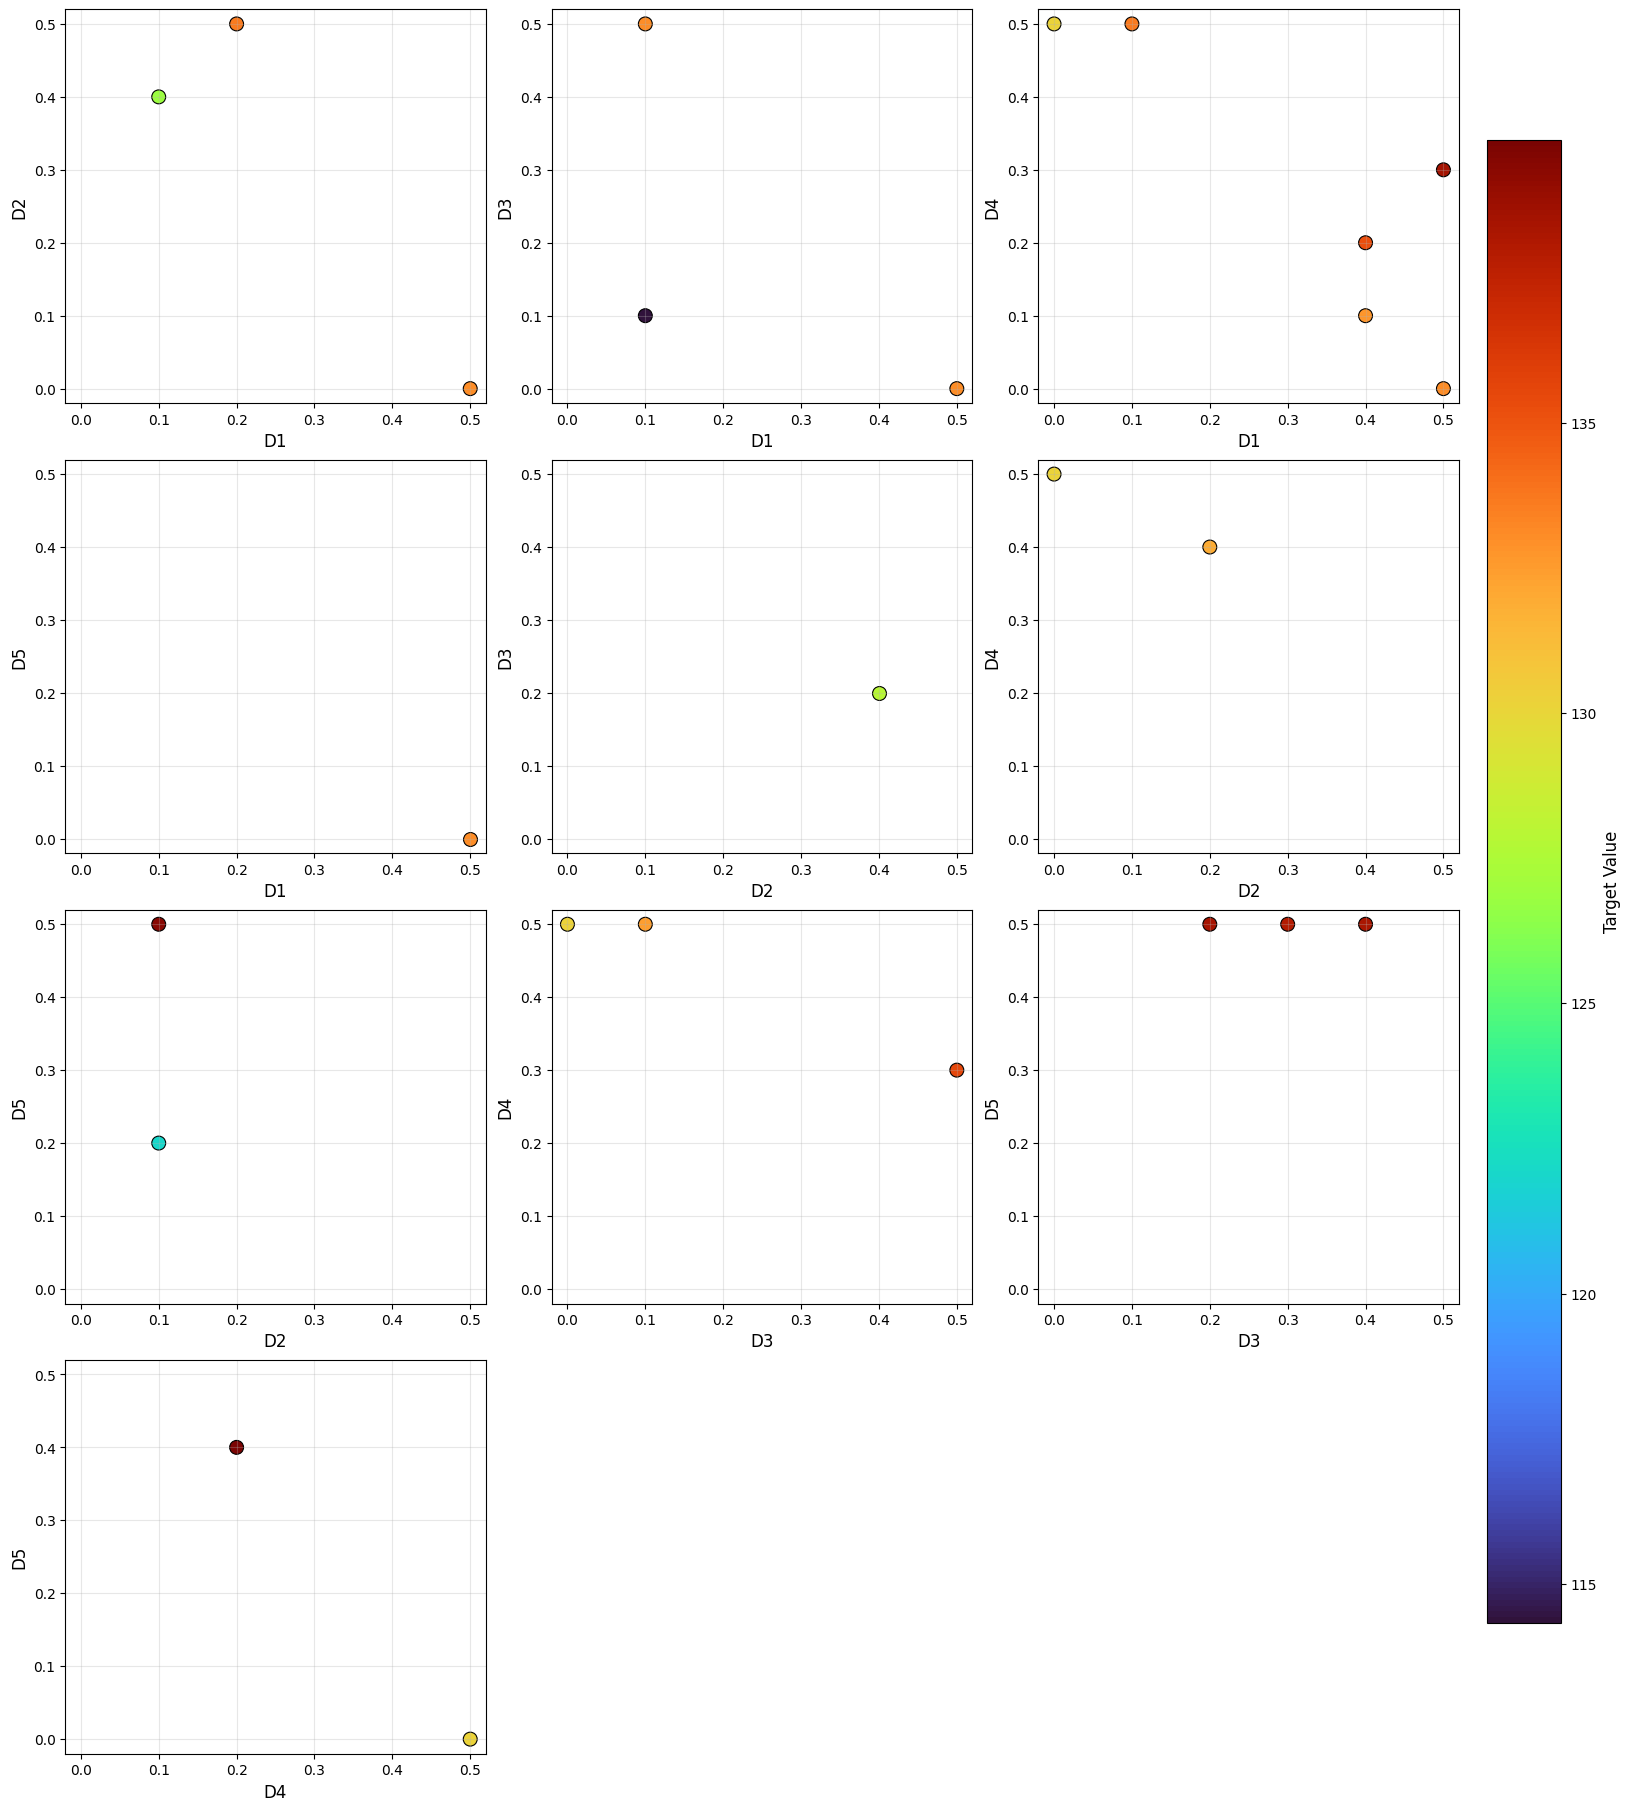

In [2]:
df_original=pd.read_csv(path1, index_col=0)
df_original_descriptor=df_original[desc_columns]

df_fill = df_original.dropna()
df_vacant =df_original[df_original[target_column].isnull()]
df_vacant_descriptor=df_vacant[desc_columns]

df_descriptor = df_fill[desc_columns]
df_target = df_fill[target_column]

all_x=df_original_descriptor.values

train_x=df_descriptor.values
train_y=df_target.values.reshape(-1,1)

unknown_x=df_vacant_descriptor.values 

""" メモ

train_x (numpy)  既知材料の記述子行列
train_y (numpy)  既知材料の目的変数
all_x (numpy)  全データの記述子行列
unknown_x (numpy) 未知データの記述子行列
df_original (Pandas) 全データ行列

"""
display(df_original)

#plot_2ddescriptors(train_x[:,0], train_x[:,1], train_y.flatten(), 100)

plot_nd_descriptors_allpairs_filtered(train_x, train_y)


# ガウス過程の実行

train_x shape (23, 5)
Likelihood -18.659980715890608


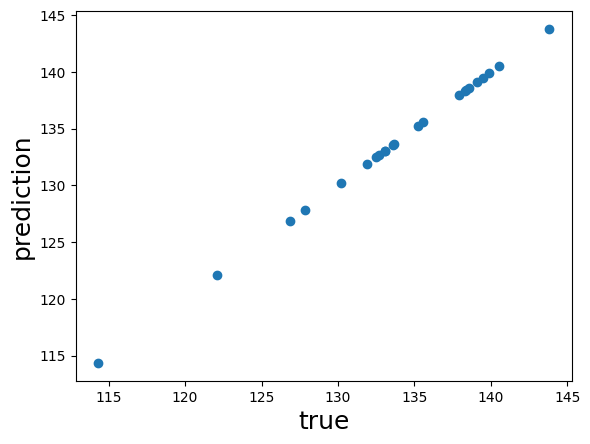

In [7]:
print("train_x shape",train_x.shape)
gpm=gpr(train_x,train_y)
print("Likelihood",gpm.log_marginal_likelihood())

GPf, GPv, GPsd=gpp(train_x, gpm)
current_ymax=np.max(train_y)

fig, ax = plt.subplots()
ax.errorbar(train_y.flatten(),GPf.flatten(),yerr=GPsd.flatten(),fmt='o')
ax.set_xlabel("true",fontsize=18)
ax.set_ylabel("prediction",fontsize=18)
plt.show()
plt.close(fig)


# 獲得関数計算（並列実験前）

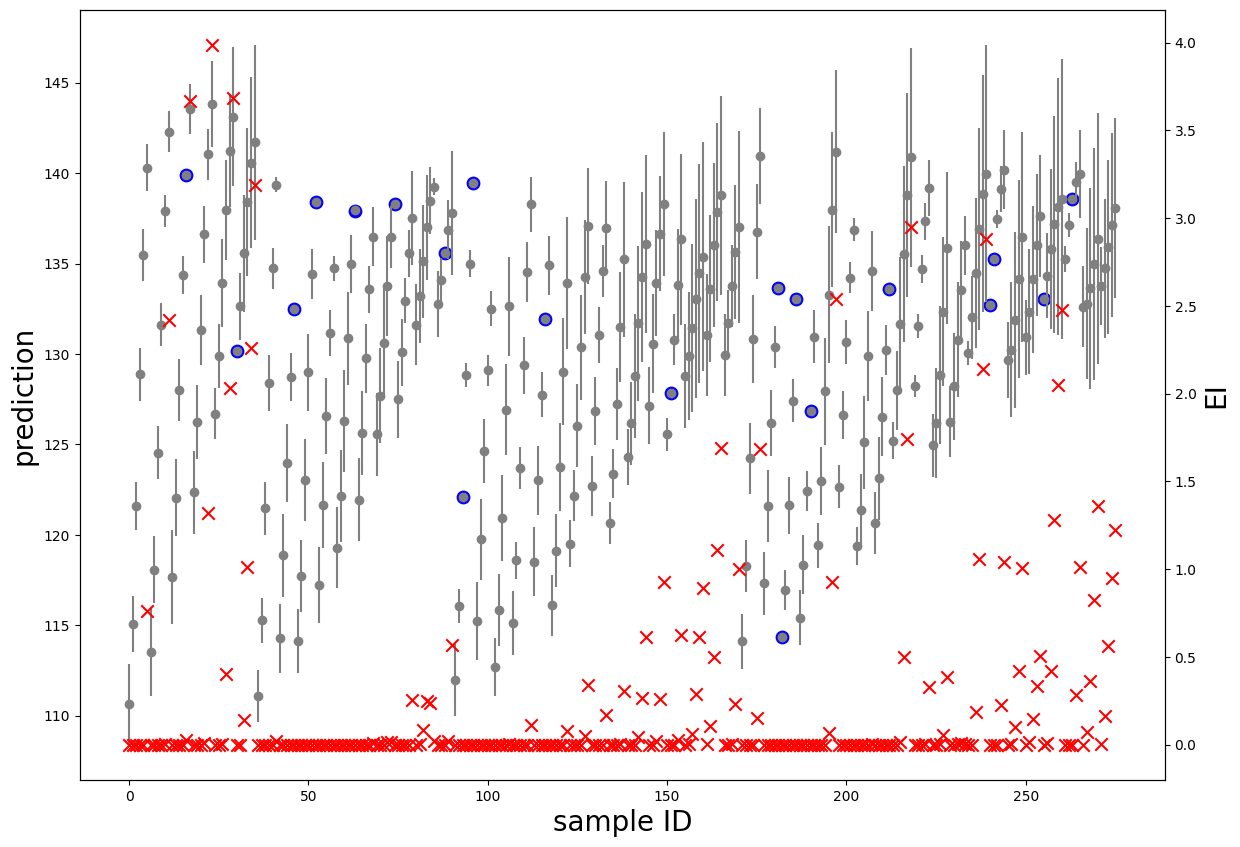

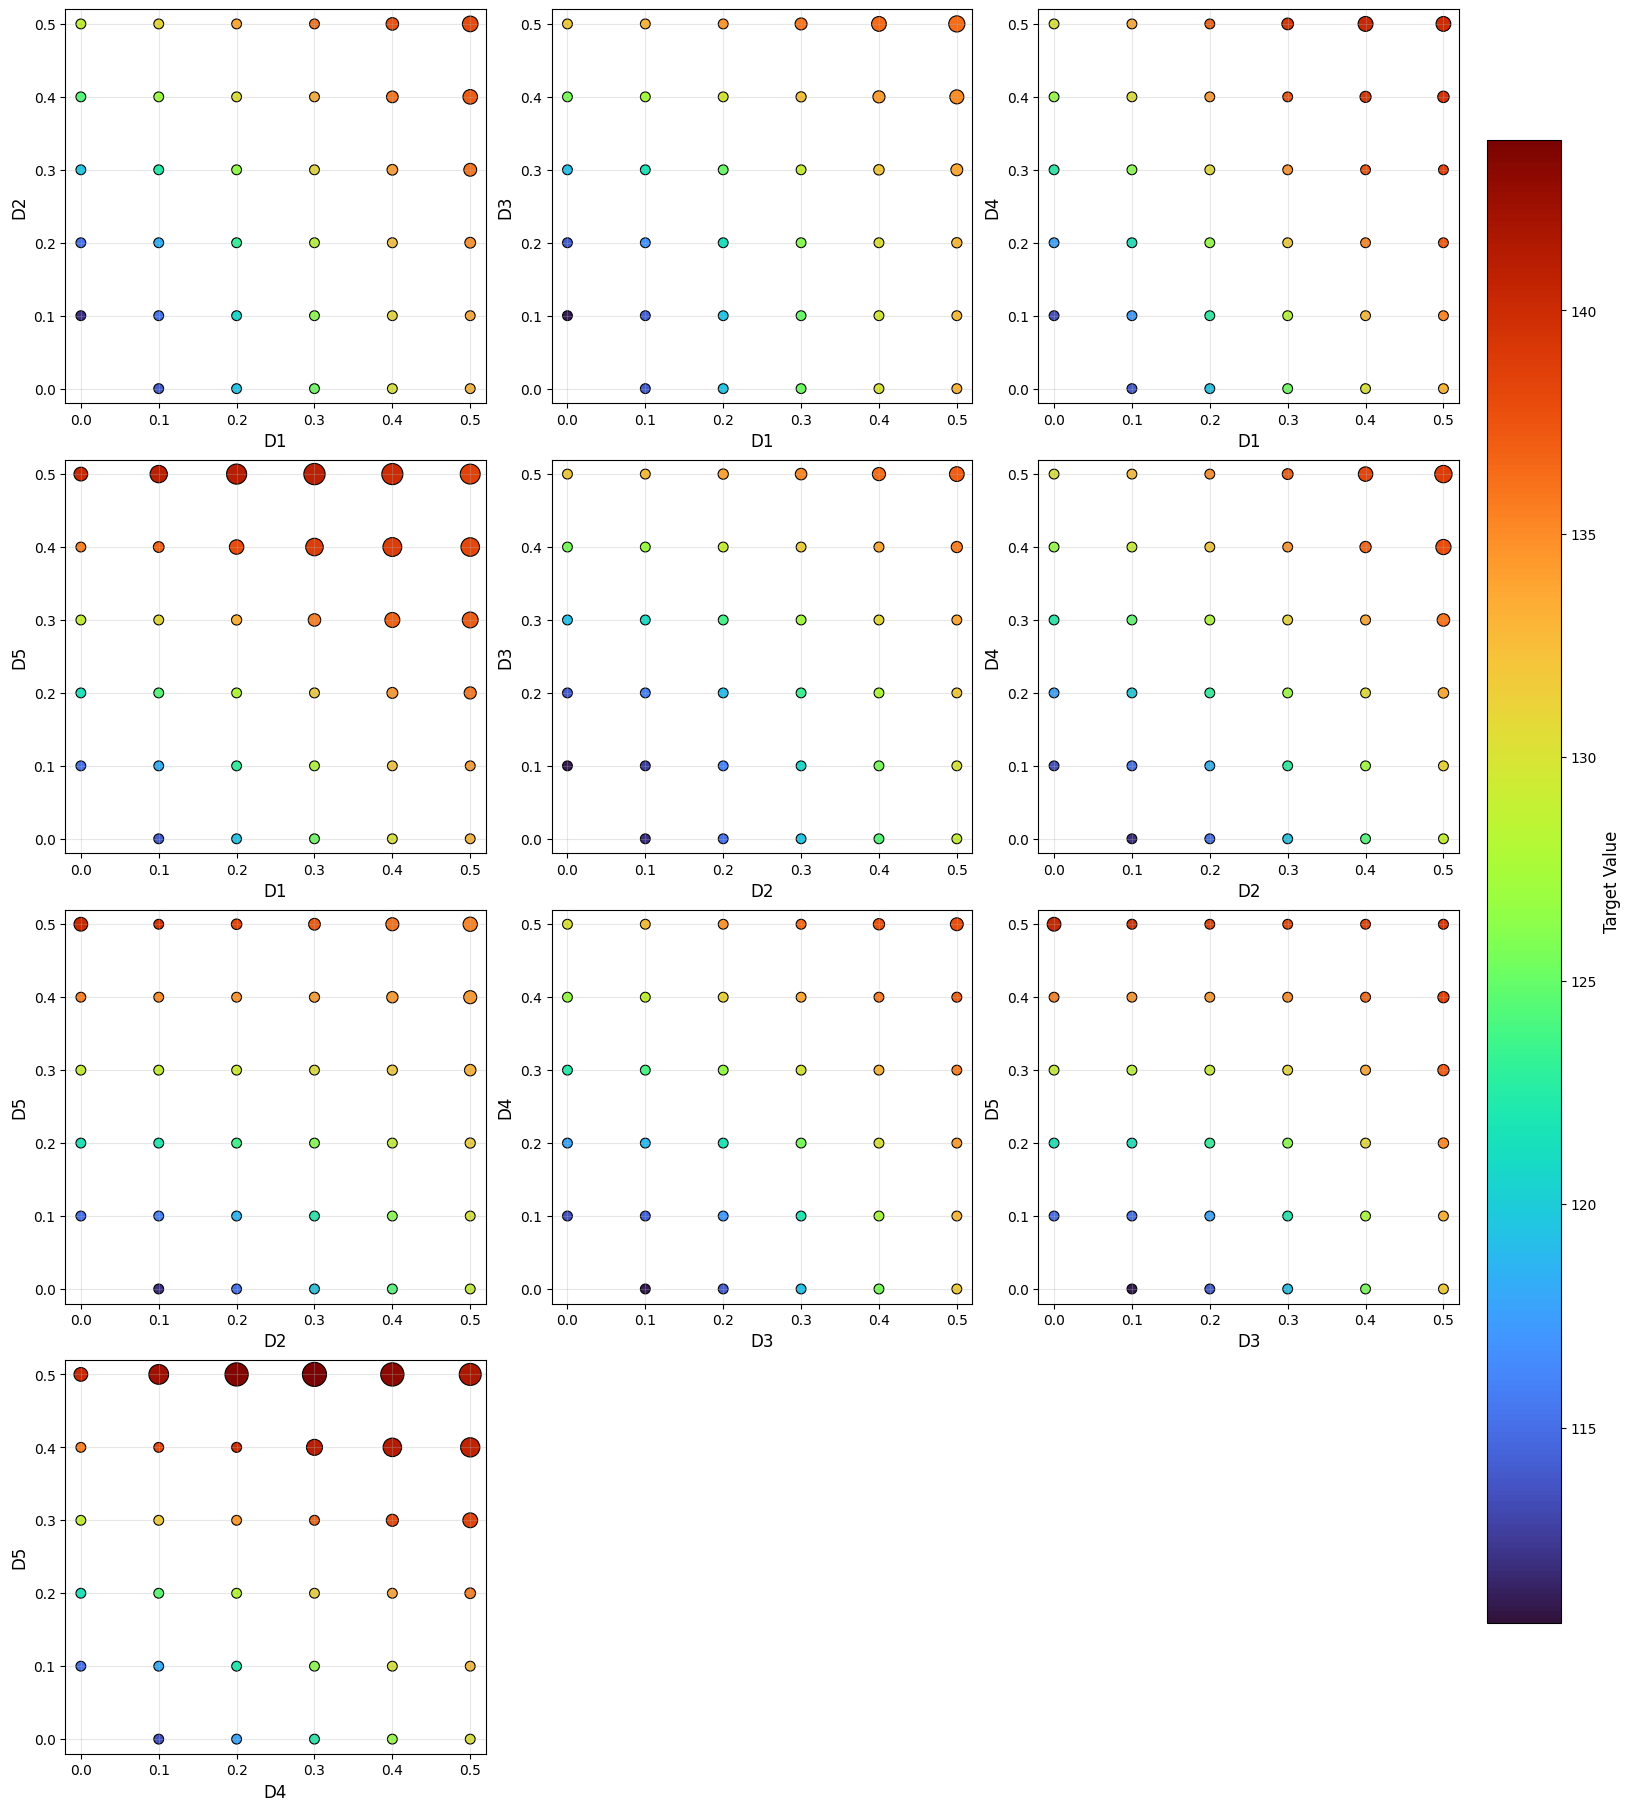

In [4]:
GPf, GPv, GPsd=gpp(all_x, gpm)
current_ymax=np.max(train_y)
tradeoff_e_val=0
ei=expected_improvement(GPf,GPsd,current_ymax,tradeoff_e_val)
max_ei_id=np.argmax(ei)

df1=pd.DataFrame(GPf,columns=['GPf'],index=df_original.index)
df2=pd.DataFrame(GPsd,columns=['GPsd'],index=df_original.index)
df3=pd.DataFrame(ei,columns=['ei'],index=df_original.index)

df=pd.concat([df_original,df1,df2,df3],axis=1)
df.to_csv(path1out)

### ここから下は必須ではない(グラフを描画するだけ)　エラーが出るときはカット   ####

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.set_xlabel("sample ID",fontsize=20)
ax1.set_ylabel("prediction",fontsize=20)
ax2.set_ylabel("EI",fontsize=20)
ax1.errorbar(range(GPf.shape[0]),GPf.flatten(),yerr=GPsd.flatten(),fmt='o',color='gray')
ax2.scatter(range(GPf.shape[0]),ei,color='red',s=80,marker='x')
ax1.scatter(range(GPf.shape[0]),df[target_column],color='blue',s=80,marker='o')
fig.set_figheight(10)  # Figure sizeの指定 (高さ)
fig.set_figwidth(14)   # Figure sizeの指定 (幅)
plt.show()
plt.close(fig)


pred = GPf.flatten()
std  = ei.flatten()

# 標準偏差をプロットサイズへ（見やすいようにスケーリング）
size1 = 50 + (std - std.min()) / (std.max() - std.min() + 1e-12) * 250
print 

plot_nd_descriptors_allpairs_filtered(all_x, pred, size=size1, use_colorbar=True)




# 獲得関数計算（並列実験後予測値）

selected indices: [23, 239, 165]


c:\Users\NakayamaLab\.conda\envs\py3-11-9\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,conc_1,conc_2,conc_3,conc_4,conc_5,truth,open,batch_rank,fantasy_mu,fantasy_sd,fantasy_ei,fantasy_y_used,open_or_fantasy
23,0.0,0.0,0.0,0.3,0.5,141.539449,NaN,1.0,143.812281,2.365864,3.987595,143.812281,143.812281
239,0.4,0.0,0.0,0.0,0.5,139.658169,NaN,2.0,140.538670,6.958880,1.441025,140.538670,140.538670
165,0.0,0.5,0.0,0.5,0.0,138.487388,NaN,3.0,133.608625,6.467940,0.158459,133.608625,139.085099


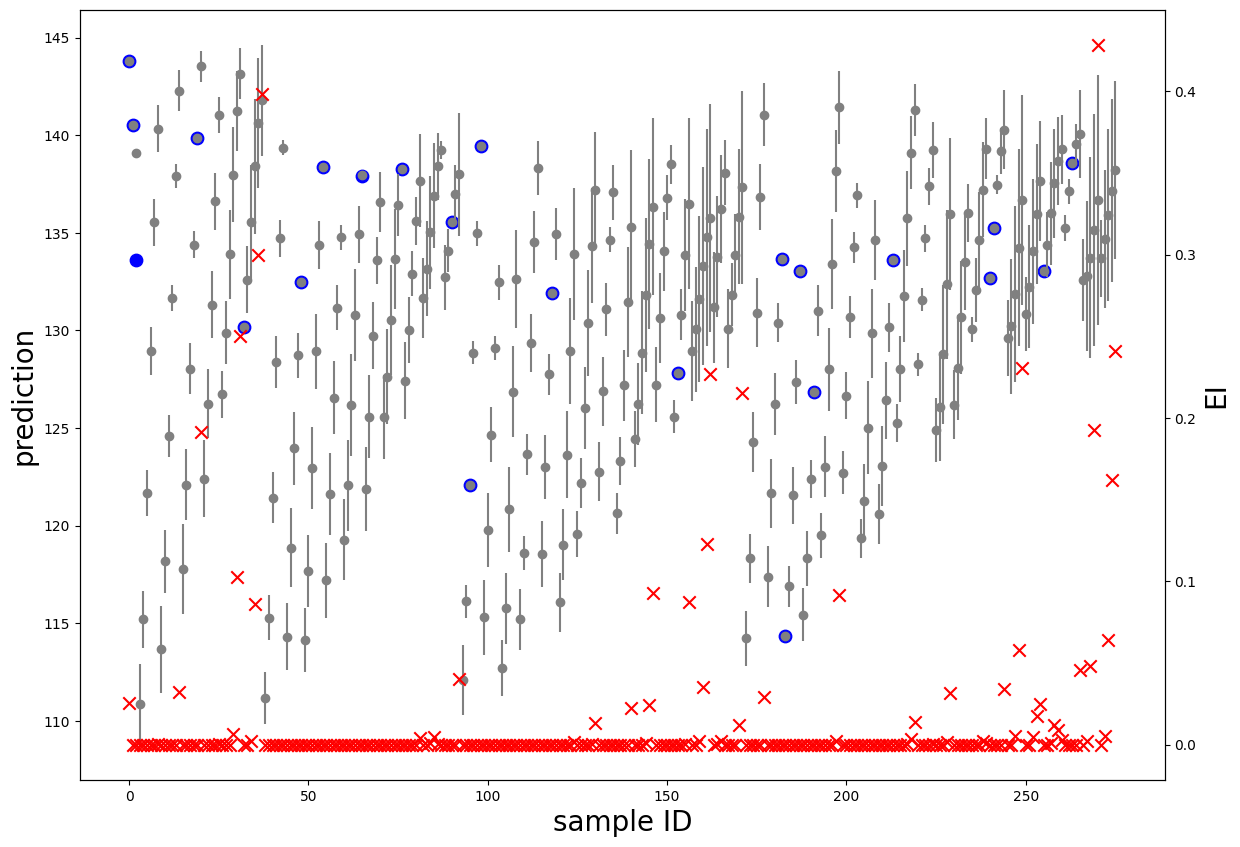

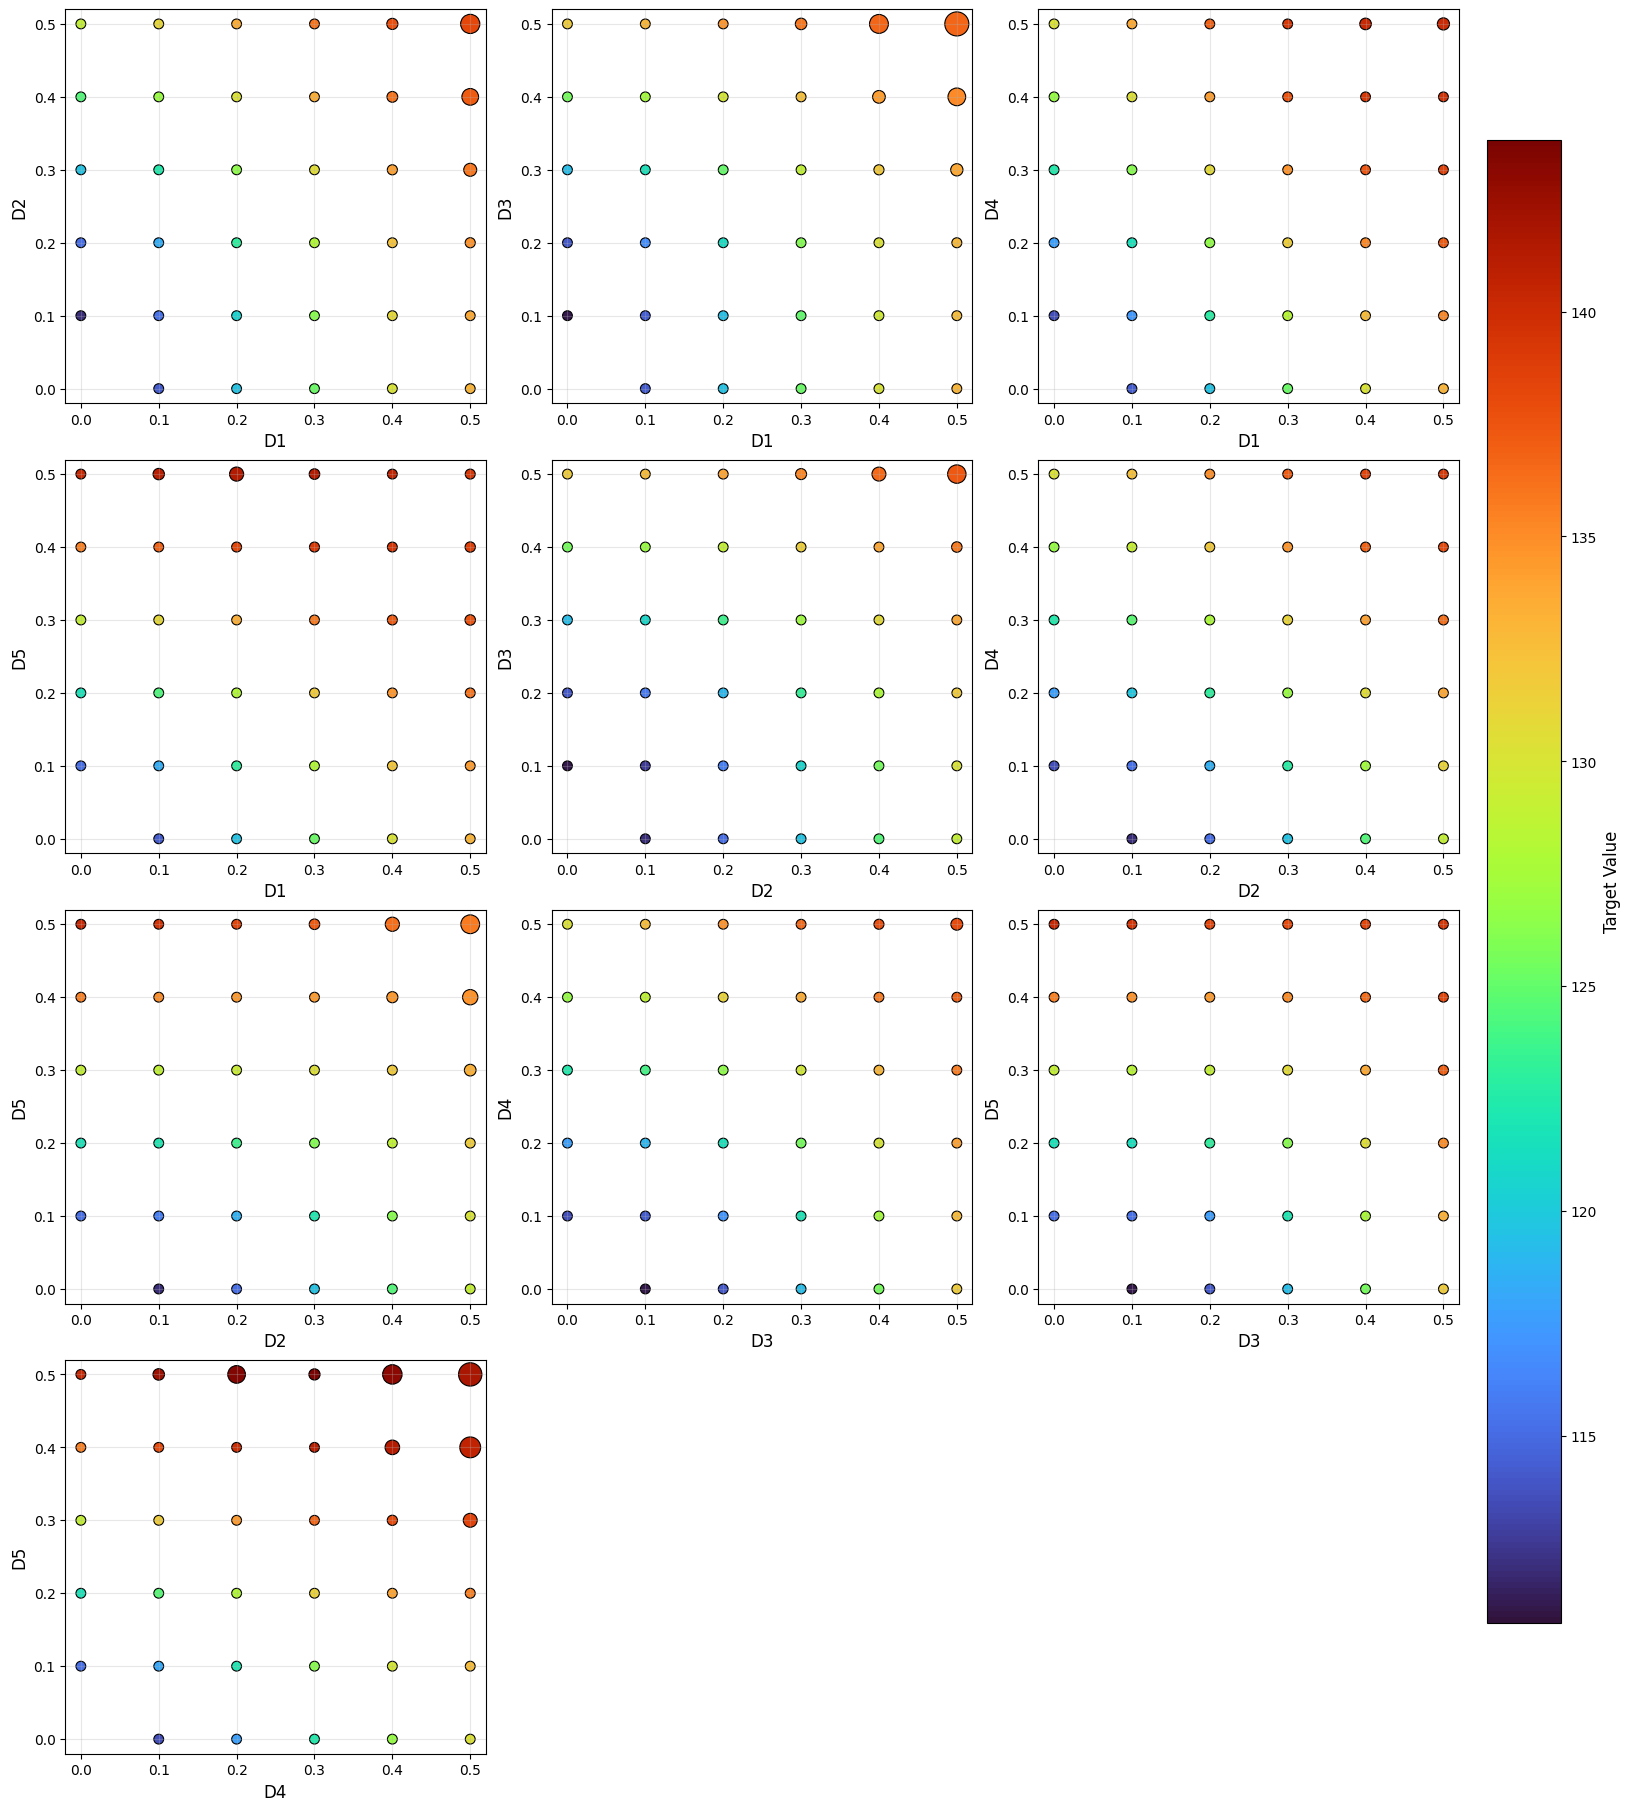

In [8]:
feature_cols = [c for c in df_original.columns if c.startswith("conc_")]

df_ranked, batch_indices, batch_rows = rank_candidates_sequential_fantasy(
    df_original=df_original,
    feature_cols=feature_cols,
    target_column=target_column,
    open_column="open",
    batch_size=batch_size,
    tradeoff_e_val=0.0,
    fantasy_mode="mean"
)

print("selected indices:", batch_indices)
display(batch_rows)


##再計算 

target_column="open_or_fantasy"
df_original=df_ranked
df_original_descriptor=df_original[desc_columns]

df_fill = df_original.dropna(subset=[target_column])
df_vacant =df_original[df_original[target_column].isnull()]
df_vacant_descriptor=df_vacant[desc_columns]

df_descriptor = df_fill[desc_columns]
df_target = df_fill[target_column]

all_x=df_original_descriptor.values

train_x=df_descriptor.values
train_y=df_target.values.reshape(-1,1)

GPf, GPv, GPsd=gpp(all_x, gpm)
current_ymax=np.max(train_y)
tradeoff_e_val=0
ei=expected_improvement(GPf,GPsd,current_ymax,tradeoff_e_val)
max_ei_id=np.argmax(ei)


### ここから下は必須ではない(グラフを描画するだけ)　エラーが出るときはカット   ####

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.set_xlabel("sample ID",fontsize=20)
ax1.set_ylabel("prediction",fontsize=20)
ax2.set_ylabel("EI",fontsize=20)
ax1.errorbar(range(GPf.shape[0]),GPf.flatten(),yerr=GPsd.flatten(),fmt='o',color='gray')
ax2.scatter(range(GPf.shape[0]),ei,color='red',s=80,marker='x')
ax1.scatter(range(GPf.shape[0]),df_original[target_column],color='blue',s=80,marker='o')
fig.set_figheight(10)  # Figure sizeの指定 (高さ)
fig.set_figwidth(14)   # Figure sizeの指定 (幅)
plt.show()
plt.close(fig)

pred = GPf.flatten()
std  = ei.flatten()

# 標準偏差をプロットサイズへ（見やすいようにスケーリング）
size1 = 50 + (std - std.min()) / (std.max() - std.min() + 1e-12) * 250
print 

plot_nd_descriptors_allpairs_filtered(all_x, pred, size=size1, use_colorbar=True)


In [ ]:
df_vacant

In [ ]:
len(df_original["open_or_fantasy"].dropna())